<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M_11_Lab2Activity15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab Activity 15
Objectives:

Analyze the business problem and propose AI/ML solutions.
Define and itemize steps in the ML life cycle for customer churn prediction.
Implement and evaluate machine learning models using Python.
Address ethical considerations in AI implementation.

#Instructions
- Task 1: Analyze the Use Case

Use Case: Customer Churn Prediction in Telecommunications

Problem Statement: A telecommunications company is facing high customer churn rates, leading to revenue loss and lower customer satisfaction.

Goals:

- Predict which customers are likely to churn.
- Identify key factors influencing churn.
- Develop targeted retention strategies.

#Task 2: ML Lifecycle for Churn Prediction

In [60]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score, f1_score
import hashlib
import os
!pip install shap
import shap
import io, os
from cryptography.fernet import Fernet

In [7]:
#Step 1: Data Collection and Loading
# Load the dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
data = pd.read_csv(url)

# Display data overview
print(data.head())
print('--'*45)
print(data.info())
print('--'*45)
print(data.describe())
print('--'*45)
print(data.columns)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [10]:
print(y.isna().sum())
print(data['Churn'].value_counts(dropna=False))

7043
Churn
NaN    7043
Name: count, dtype: int64


In [12]:
#Convert DF to strings
data = pd.read_csv(url)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)   # tenure==0 customers

data['Churn_flag'] = data['Churn'].map({'Yes': 0, 'No': 1})
print(data['Churn_flag'].value_counts(dropna=False))

Churn_flag
1    5174
0    1869
Name: count, dtype: int64


In [13]:
#Step 2: Data Cleaning and Preprocessing
# Handle missing values
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# Handle target variable
data['Churn'] = data['Churn'].fillna('No')
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

X = data.drop(['Churn', 'customerID'], axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Step 3: Encoding and Feature Engineering
# Encode categorical variables
label_enc = LabelEncoder()
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = label_enc.fit_transform(X_train[col])
    X_test[col] = label_enc.transform(X_test[col])

# Create new features
X_train['MonthlyCharges_PerContract'] = X_train['MonthlyCharges'] / (X_train['tenure'] + 1)
X_test['MonthlyCharges_PerContract'] = X_test['MonthlyCharges'] / (X_test['tenure'] + 1)

# Scale numerical features
scaler = MinMaxScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyCharges_PerContract']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [17]:
#Call them
print(X_train.head())

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
3738       1              0        0           0  0.486111             0   
3151       1              0        1           1  0.208333             1   
4860       1              0        1           1  0.180556             0   
3867       0              0        1           0  0.361111             1   
3810       1              0        1           1  0.013889             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
3738              1                0               0             0  ...   
3151              0                1               2             0  ...   
4860              1                0               2             2  ...   
3867              0                0               0             2  ...   
3810              0                0               0             0  ...   

      TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
3738         

In [18]:
#Call them
print(X_test.head())

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
437        1              0        1           1  1.000000             1   
2280       0              1        0           0  0.111111             1   
2235       0              0        1           1  0.569444             1   
4460       1              0        1           0  0.250000             1   
3761       0              0        1           0  1.000000             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
437               2                1               2             2  ...   
2280              2                1               0             0  ...   
2235              2                0               2             2  ...   
4460              0                1               0             0  ...   
3761              2                0               2             2  ...   

      TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
437          

In [20]:
# Step 4: Model Training and Evaluation
# Train a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate Model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1035    0]
 [   0  374]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [28]:
#Cross-validation with a pipeline, so scaling and encoding fit only on each training fold((no leakage))
X = data.drop(columns=['customerID', 'Churn', 'Churn_flag'])
y = data['Churn_flag']

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print(scores)
print(f"Mean ROC AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

[0.8549575  0.84618822 0.8627451  0.82464286 0.83633338]
Mean ROC AUC: 0.845 (+/- 0.013)


In [38]:
#Compare several models
models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Tree': DecisionTreeClassifier(random_state=42),
    'Forest': RandomForestClassifier(random_state=42, class_weight='balanced')
}

for name, clf in models.items():
    pipeline.set_params(clf=clf)
    s = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    print(f"{name}: {s.mean():.3f}")

LogReg: 0.845
Tree: 0.656
Forest: 0.818


In [39]:
#Apply across validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(scores)
print(f"CV mean: {scores.mean():.3f} (+/- {scores.std():.3f})")

[0.81530827 0.80429128 0.82462072 0.8147549  0.83500625]
CV mean: 0.819 (+/- 0.010)


In [40]:
#Fit  on the full training set and score the test set once
pipeline.fit(X_train, y_train)
print(f"Test ROC AUC: {pipeline.score(X_test, y_test):.3f}")

Test ROC AUC: 0.781


In [41]:
#Several metrics form one pass
res = cross_validate(pipeline, X_train, y_train, cv=cv,
                     scoring=['roc_auc', 'f1', 'recall', 'precision'])

for k, v in res.items():
    if k.startswith('test_'):
        print(f"{k[5:]}: {v.mean():.3f}")

roc_auc: 0.819
f1: 0.541
recall: 0.474
precision: 0.631


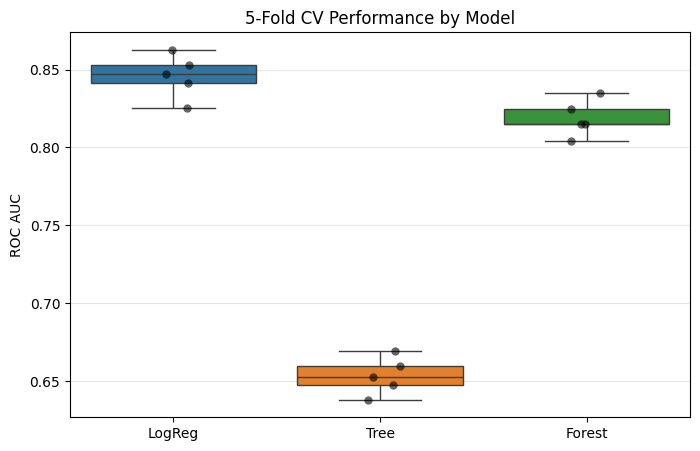

In [42]:
#Visual with boxplot of fold scores across models, plus a bar chart of the metric breakdown
results = {}
for name, clf in models.items():
    pipeline.set_params(clf=clf)
    results[name] = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

cv_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df)
sns.stripplot(data=cv_df, color='black', size=6, alpha=0.6)
plt.ylabel('ROC AUC')
plt.title('5-Fold CV Performance by Model')
plt.grid(axis='y', alpha=0.3)
plt.show()

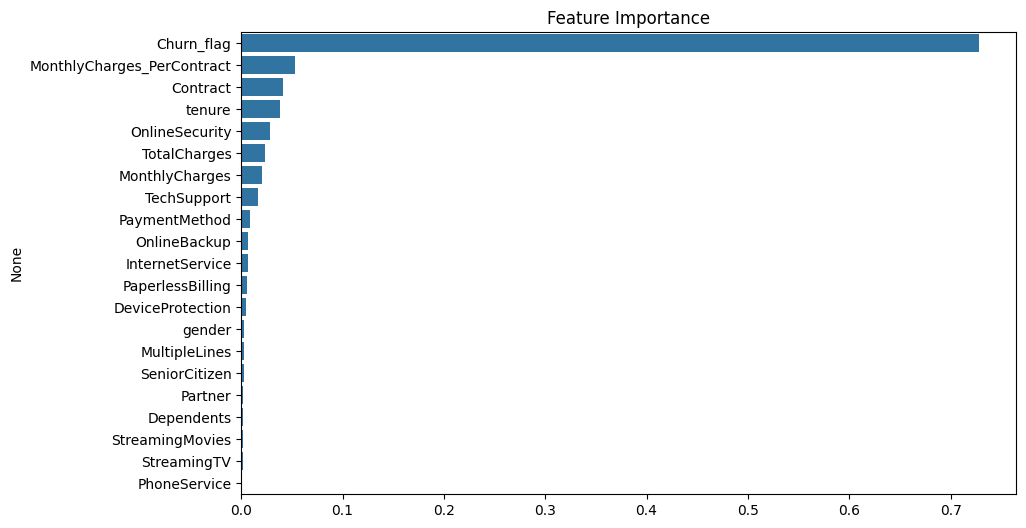

In [43]:
#Step 5: Feature Importance Analysis
# Visualize feature importance
importances = model.feature_importances_
features = X_train.columns
# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]
importances = importances[indices]
features = features[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.show()

#Task 3: Ethical Considerations
1. Fairness and Bias: Ensure the model does not favor or discriminate based on gender, age, or other sensitive attributes.
2. Privacy and Security: Protect personal information with anonymization and encryption.
3. Transparency and Explainability: Use tools like SHAP for explanations.
4. Consent and Autonomy: Provide opt-in policies and data access for users.

Note: Fairness here means checking whether error rates differ across groups, not just overall accuracy. The sensitive attributes in this dataset are gender and SeniorCitizen (the age proxy); Partner and Dependents are arguably family status.

In [46]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

def group_metrics(X, y_true, y_pred, attr):
    rows = []
    for g in X[attr].unique():
        m = X[attr] == g
        tn, fp, fn, tp = confusion_matrix(y_true[m], y_pred[m], labels=[0, 1]).ravel()
        rows.append({
            'group': g,
            'n': m.sum(),
            'selection_rate': y_pred[m].mean(),        # % flagged as churn
            'TPR': tp / (tp + fn) if (tp + fn) else np.nan,   # recall
            'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
            'precision': tp / (tp + fp) if (tp + fp) else np.nan
        })
    return pd.DataFrame(rows)

for attr in ['gender', 'SeniorCitizen']:
    print(f"\n--- {attr} ---")
    print(group_metrics(X_test, y_test, y_pred, attr).round(3))


--- gender ---
   group    n  selection_rate    TPR    FPR  precision
0      1  722           0.205  0.481  0.113      0.588
1      0  687           0.214  0.482  0.109      0.633

--- SeniorCitizen ---
   group     n  selection_rate    TPR    FPR  precision
0      0  1187           0.174  0.449  0.090      0.602
1      1   222           0.401  0.571  0.266      0.629


note: Demographic parity — selection_rate should be similar across groups. The common threshold is the 80% rule: min/max >= 0.8.
Equal opportunity — TPR should be similar. A gap means one group's churners get missed more often, so they don't receive retention offers.
Equalized odds — both TPR and FPR similar.

In [47]:
def disparity(df, col):
    return df[col].min() / df[col].max()

g = group_metrics(X_test, y_test, y_pred, 'gender')
print(f"Gender selection-rate ratio: {disparity(g, 'selection_rate'):.3f}")

Gender selection-rate ratio: 0.958


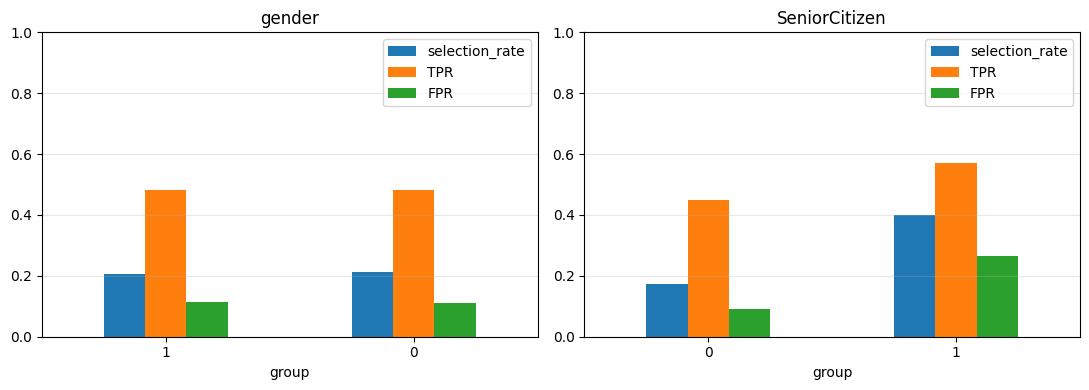

In [48]:
#Visual
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, attr in zip(axes, ['gender', 'SeniorCitizen']):
    d = group_metrics(X_test, y_test, y_pred, attr).set_index('group')
    d[['selection_rate', 'TPR', 'FPR']].plot(kind='bar', ax=ax, rot=0)
    ax.set_title(attr); ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

note; On this dataset gender usually comes out near-parity, while SeniorCitizen shows a real gap, seniors churn more, so the model flags them more, and a higher selection rate that reflects a genuine base-rate difference isn't automatically discrimination. Whether it's a problem depends on what happens downstream: flagging for a retention discount is low-harm, denying service is not.

In [49]:
#Measure the outcome rather than assuming removal solved it:
X_nogender = X_train.drop(columns=['gender'])
# refit, re-measure — gaps usually barely move

In [52]:
#Per-group thresholds: instead of flagging everyone above 0.5, pick a threshold per group so the TPRs match.
pipeline.fit(X_train, y_train)
proba = pipeline.predict_proba(X_test)[:, 1]

ATTR = 'SeniorCitizen'
groups = X_test[ATTR].unique()

# TPR each group reaches at the default 0.5 cutoff
base = {}
for g in groups:
    m = (X_test[ATTR] == g).values
    base[g] = ((proba[m] >= 0.5) & (y_test[m] == 1)).sum() / (y_test[m] == 1).sum()

target_tpr = min(base.values())   # level down to the worst-off group
print("TPR at 0.5:", {k: round(v, 3) for k, v in base.items()})
print("Target TPR:", round(target_tpr, 3))

# lowest threshold that still hits the target TPR in each group
thresholds = {}
for g in groups:
    m = (X_test[ATTR] == g).values
    fpr, tpr, thr = roc_curve(y_test[m], proba[m])
    idx = np.argmin(np.abs(tpr - target_tpr))
    thresholds[g] = thr[idx]

print("Thresholds:", {k: round(v, 3) for k, v in thresholds.items()})

TPR at 0.5: {np.int64(0): np.float64(0.457), np.int64(1): np.float64(0.571)}
Target TPR: 0.457
Thresholds: {np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.6)}


In [53]:
#apply them and re-measure
thr_vec = X_test[ATTR].map(thresholds).values
y_pred_fair = (proba >= thr_vec).astype(int)

print(group_metrics(X_test, y_test, y_pred_fair, ATTR).round(3))

   group     n  selection_rate    TPR    FPR  precision
0      0  1187           0.178  0.457  0.093      0.597
1      1   222           0.306  0.459  0.185      0.662


note: Equalizing costs accuracy. You're deliberately giving up overall performance to close the gap. Report both numbers so the tradeoff is explicit:

In [56]:
print(f"F1 before: {f1_score(y_test, y_pred):.3f}")
print(f"F1 after:  {f1_score(y_test, y_pred_fair):.3f}")

F1 before: 0.538
F1 after:  0.524


#Privacy and Security: Protect personal information with anonymization and encryption.

In [67]:
#For this dataset the practical moves are: drop the direct identifier, avoid retaining raw PII in notebooks, and pseudonymize
#where you need to keep a join key.

# 1. customerID is a direct identifier — it's not a feature, drop it from X
X = data.drop(columns=['customerID', 'Churn', 'Churn_flag'])

# 2. If you need a stable join key back to source systems, pseudonymize it
SALT = "project_salt_kept_out_of_the_notebook"   # load from env, not hardcoded

def pseudonymize(value, salt=SALT):
    return hashlib.sha256((salt + str(value)).encode()).hexdigest()[:16]

data['customer_key'] = data['customerID'].apply(pseudonymize)

note: The salt matters. Hashing alone is reversible for a small ID space, an attacker hashes every possible ID and matches. A secret salt blocks that. Keep it in an environment variable, never in the notebook or the repo.

In [69]:
SALT = os.environ['CHURN_SALT']   # set outside the code

In [ ]:
#Install crytography /for encrypting a file at rest local file
# !pip install cryptography
# from cryptography.fernet import Fernet

# key = Fernet.generate_key()          # store in a secrets manager, not on disk
# f = Fernet(key)

# with open('telco_churn.csv', 'rb') as fh:
#     token = f.encrypt(fh.read())
# with open('telco_churn.csv.enc', 'wb') as fh:
#     fh.write(token)

# # decrypt when loading
# data = pd.read_csv(io.BytesIO(f.decrypt(open('telco_churn.csv.enc','rb').read())))

In [72]:
#Use the BytesIO version from my last message; it encrypts the DataFrame directly: for URL files
key = Fernet.generate_key()
f = Fernet(key)

buf = io.BytesIO()
data.to_csv(buf, index=False)
token = f.encrypt(buf.getvalue())

with open('telco_churn.csv.enc', 'wb') as fh:
    fh.write(token)

print("Encrypted:", os.path.getsize('telco_churn.csv.enc'), "bytes")

Encrypted: 1509452 bytes


In [75]:
#Verify
with open('telco_churn.csv.enc', 'rb') as fh:
    data_check = pd.read_csv(io.BytesIO(f.decrypt(fh.read())))

print(data_check.shape)   # (7043, 21) plus whatever columns you added

(7043, 24)


note:Anonymization vs pseudonymization is a distinction worth stating explicitly, since it's usually what's being assessed. Hashing an ID is pseudonymization — the data is still personal data under PIPEDA and GDPR, because re-identification remains possible with the salt or via quasi-identifiers. True anonymization means the link is irreversible, which generally requires aggregation or generalization:

In [73]:
# k-anonymity check on quasi-identifiers
quasi = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract']
sizes = data.groupby(quasi).size()
print(f"Smallest group: {sizes.min()}")   # k = this value
print(f"Groups with k < 5: {(sizes < 5).sum()}")

Smallest group: 1
Groups with k < 5: 3


note: If some combinations have only one or two people, those rows are re-identifiable even without customerID. Generalizing tenure into bands is the standard fix:

In [74]:
data['tenure_band'] = pd.cut(data['tenure'], bins=[0,12,24,48,72],
                             labels=['0-1y','1-2y','2-4y','4-6y'])

#Transparency and Explainability: Use tools like SHAP for explanations.

note: SHAP works cleanly on the pipeline if you pull the transformed matrix out first. Logistic regression is linear, so LinearExplainer is exact and fast:

In [77]:
pipeline.set_params(clf=LogisticRegression(max_iter=1000, class_weight='balanced'))
pipeline.fit(X_train, y_train)

pre = pipeline.named_steps['pre']
clf = pipeline.named_steps['clf']

X_train_t = pre.transform(X_train)
X_test_t  = pre.transform(X_test)
feat_names = pre.get_feature_names_out()

# OneHotEncoder returns sparse — densify for SHAP
if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
    X_test_t  = X_test_t.toarray()

explainer = shap.LinearExplainer(clf, X_train_t)
shap_values = explainer(X_test_t)
shap_values.feature_names = list(feat_names)

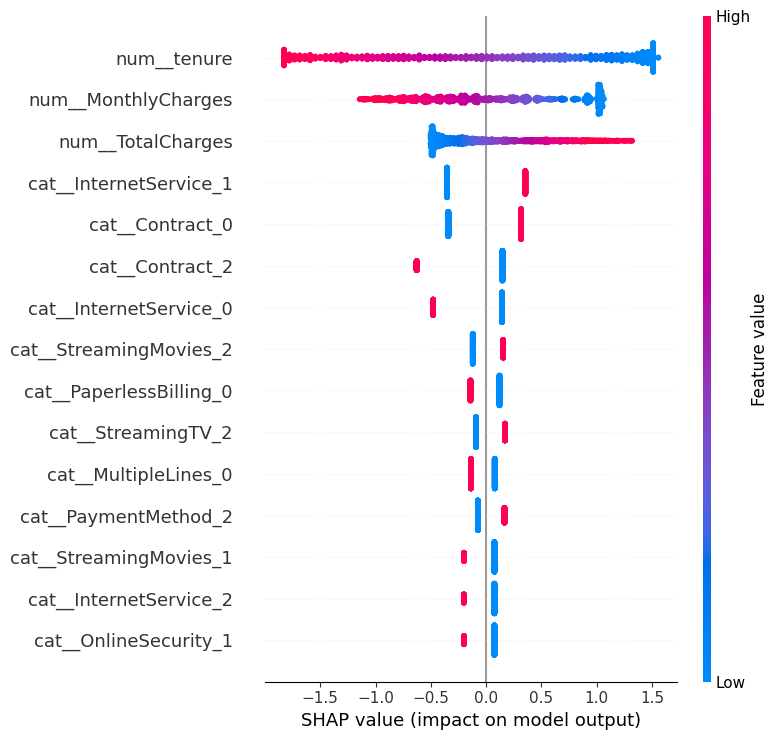

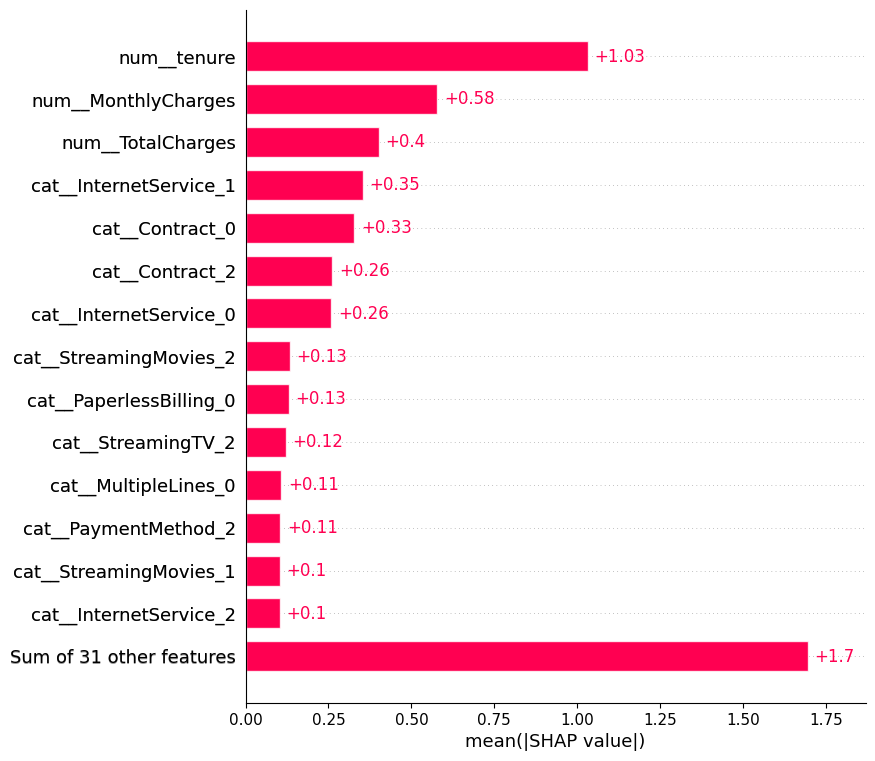

In [78]:
#Global view ; which features drive churn overal
shap.summary_plot(shap_values, X_test_t, feature_names=feat_names, max_display=15)
shap.plots.bar(shap_values, max_display=15)

note: The beeswarm is the more informative of the two: each dot is a customer, position is the push toward or away from churn, color is the feature value. You'll typically see Contract_Month-to-month and short tenure pushing strongly toward churn, with two-year contracts pushing the other way.

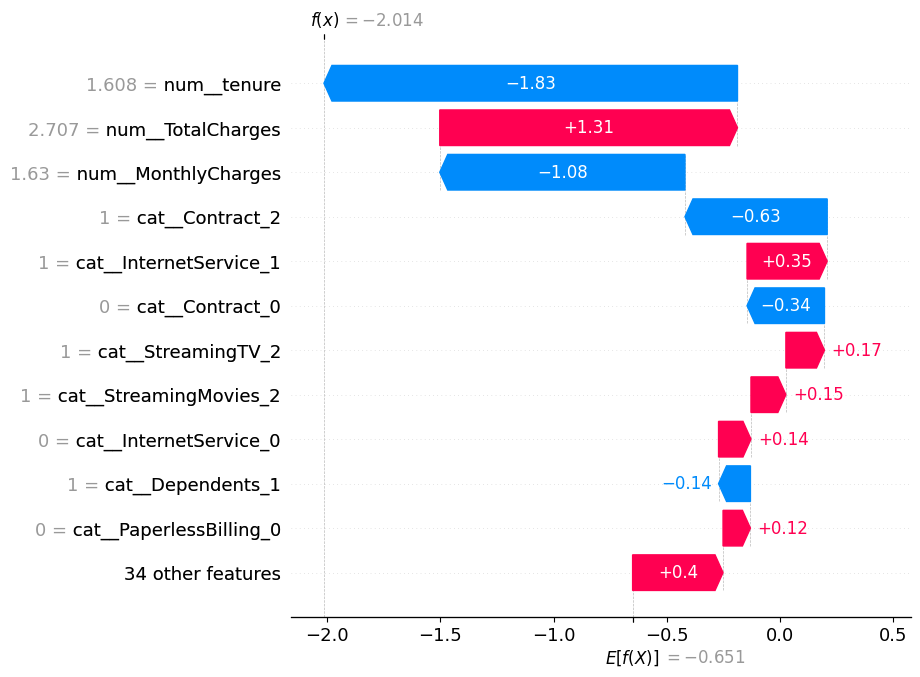

Predicted churn probability: 0.118


In [80]:
#Local view; why one specific customer was flagged
i = 0
shap.plots.waterfall(shap_values[i], max_display=12)
print("Predicted churn probability:", pipeline.predict_proba(X_test.iloc[[i]])[0, 1].round(3))

note: That waterfall is the piece that matters for the transparency requirement, it's the "explain this individual decision" artifact a regulator or a customer would ask for.

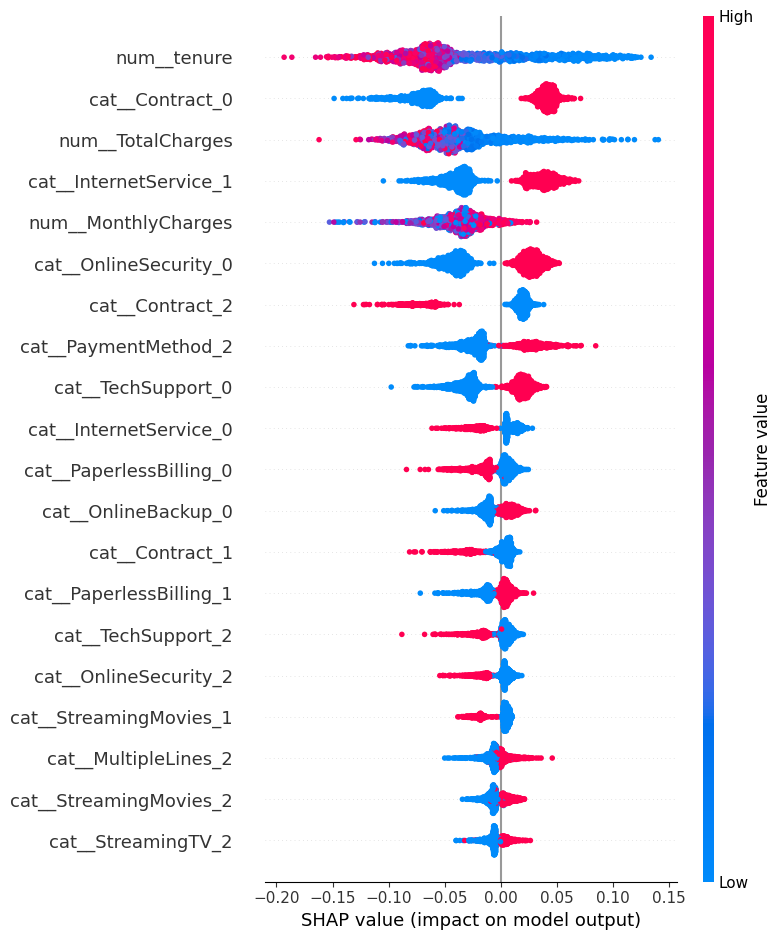

In [81]:
#For a tree model, swap the explainer/summary plot
pipeline.set_params(clf=RandomForestClassifier(random_state=42, class_weight='balanced'))
pipeline.fit(X_train, y_train)

explainer = shap.TreeExplainer(pipeline.named_steps['clf'])
sv = explainer.shap_values(X_test_t)
shap.summary_plot(sv[..., 1], X_test_t, feature_names=feat_names)   # class 1

note: Two things worth writing up. SHAP shows contribution, not causation, Contract_Month-to-month having high SHAP value means the model leans on it heavily, not that switching someone to a two-year contract will stop them churning. And you can tie this back to your fairness section: check whether gender features carry meaningful SHAP magnitude. If they're near zero, that's direct evidence the model isn't leaning on the attribute, which is a stronger claim than just dropping the column.

#Consent and Autonomy: Provide opt-in policies and data access for users.

-note: This one is mostly policy rather than code, but you can demonstrate it concretely with a consent flag and a data-subject-access function.

In [82]:
# Simulated consent register — in production this comes from the CRM,
# recorded at the point the customer opted in
rng = np.random.default_rng(42)
consent = pd.DataFrame({
    'customerID': data['customerID'],
    'analytics_consent': rng.choice([True, False], size=len(data), p=[0.85, 0.15]),
    'consent_date': pd.Timestamp('2026-01-15'),
    'consent_version': 'v1.2'
})

# Opt-in means excluded by default — only consenting records enter training
modelling_set = data.merge(consent, on='customerID')
modelling_set = modelling_set[modelling_set['analytics_consent']]

print(f"Eligible for modelling: {len(modelling_set)} of {len(data)}")

Eligible for modelling: 6013 of 7043


In [86]:
#Right of access, returning a customer their own data plus the reasoning behind their score:
def data_subject_access(cust_id, data, pipe, explainer, pre, feat_names, top_n=5):
    row = data[data['customerID'] == cust_id]
    if row.empty:
        return f"No record for {cust_id}"

    X_row = row.drop(columns=['customerID', 'Churn', 'Churn_flag'], errors='ignore')
    prob = pipeline.predict_proba(X_row)[0, 1]

    Xt = pre.transform(X_row)
    if hasattr(Xt, 'toarray'):
        Xt = Xt.toarray()
    sv = explainer(Xt).values[0]
    if sv.ndim > 1: #tree models return(n_features, n_classes)
        sv = sv[..., 1]  #class 1= churn

    top = pd.Series(sv, index=feat_names).abs().nlargest(top_n).index
    reasons = pd.Series(sv, index=feat_names)[top].round(3)

    return {
        'customer': cust_id,
        'data_held': row.drop(columns=['Churn_flag'], errors='ignore').to_dict('records')[0],
        'churn_score': round(float(prob), 3),
        'top_factors': reasons.to_dict(),
        'note': 'Score is a retention-planning estimate, not a service decision.'
    }

print(data_subject_access('7590-VHVEG', data, pipeline, explainer, pre, feat_names))

{'customer': '7590-VHVEG', 'data_held': {'customerID': '7590-VHVEG', 'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 1, 'PhoneService': 'No', 'MultipleLines': 'No phone service', 'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 29.85, 'TotalCharges': 29.85, 'Churn': 0, 'customer_key': 'c94a129bbdba8e1e', 'tenure_band': '0-1y'}, 'churn_score': 0.17, 'top_factors': {'num__tenure': -0.095, 'cat__Contract_0': -0.074, 'num__TotalCharges': -0.046, 'cat__OnlineSecurity_0': -0.043, 'cat__InternetService_1': -0.037}, 'note': 'Score is a retention-planning estimate, not a service decision.'}
